# 1. Imports

In [1]:
import os, json, cv2, numpy as np, matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.transforms import functional as F

import albumentations as A # Library for augmentations

In [2]:
import sys
sys.path.append('pytorch_vision')

In [3]:
from pytorch_vision import transforms, utils, engine, train
# from pytorch_vision import transforms, utils, engine, train
from utils import collate_fn
from engine import train_one_epoch, evaluate

# 2. Augmentations

In [ ]:
def train_transform():
    return A.Compose([
        A.Sequential([
            A.RandomRotate90(p=1), # Random rotation of an image by 90 degrees zero or more times
            A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, brightness_by_max=True, always_apply=False, p=1), # Random change of brightness & contrast
        ], p=1)
    ],
    keypoint_params=A.KeypointParams(format='xy', remove_invisible=False), # More about keypoint formats used in albumentations library read at https://albumentations.ai/docs/getting_started/keypoints_augmentation/
    bbox_params=A.BboxParams(format='pascal_voc', label_fields=['bboxes_labels']) # Bboxes should have labels, read more here https://albumentations.ai/docs/getting_started/bounding_boxes_augmentation/
    )

# 3. Dataset class

In [ ]:
class ClassDataset(Dataset):
    def __init__(self, root, transform=None, demo=False):                
        self.root = root
        self.transform = transform
        self.demo = demo # Use demo=True if you need transformed and original images (for example, for visualization purposes)
        self.imgs_files = sorted(os.listdir(os.path.join(root, "images")))
        # self.annotations_files = sorted(os.listdir(os.path.join(root, "annotations")))
        # find the json annnotations file
        self.annotations_file = [f for f in os.listdir(os.path.join(root, "annotations")) if f.endswith('.json')][0] # Assuming there is only one json file in the annotations folder
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.root, "images", self.imgs_files[idx])
        annotations_path = os.path.join(self.root, "annotations", self.annotations_file)

        img_original = cv2.imread(img_path)
        img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)        
        
        # with open(annotations_path) as f:
        #     data = json.load(f)
        #     bboxes_original = data['bboxes']
        #     keypoints_original = data['keypoints']
            
        #     # All objects are glue tubes
        #     bboxes_labels_original = ['Glue tube' for _ in bboxes_original]
        
        
        with open(annotations_path) as f:
            # filter json file for objects with image_id equal to idx
            data = json.load(f)
            data = data['annotations']  # Assuming the annotations are stored under the 'annotations' key
            # loop through the data and filter by image_id

            # Filter objects with image_id equal to idx
            objects = [obj for obj in data if obj['image_id'] == idx]
            # Combine bboxes and keypoints into lists
            bboxes_original = [obj['bbox'] for obj in objects]
            keypoints_original = [obj['keypoints'] for obj in objects]

            # adapt bboxes_original to the format [xmin, ymin, xmax, ymax]
            bbox = bboxes_original
            # bbox is in the format [xmin, ymin, width, height]
            bboxes_original = [[bbox[0], bbox[1], bbox[0] + bbox[2], bbox[1] + bbox[3]] for bbox in bboxes_original]

            
            # labels from category_id 
            labels = {1: 'angle_bar', 2: 'round_bar'}
            # from category_id to label
            bboxes_labels_original = [labels[obj['category_id']] for obj in objects]


        if self.transform:   
            # Converting keypoints from [x,y,visibility]-format to [x, y]-format + Flattening nested list of keypoints            
            # For example, if we have the following list of keypoints for three objects (each object has two keypoints):
            # [[obj1_kp1, obj1_kp2], [obj2_kp1, obj2_kp2], [obj3_kp1, obj3_kp2]], where each keypoint is in [x, y]-format            
            # Then we need to convert it to the following list:
            # [obj1_kp1, obj1_kp2, obj2_kp1, obj2_kp2, obj3_kp1, obj3_kp2]
            # keypoints_original_flattened = [el[0:2] for kp in keypoints_original for el in kp]
            # for debbugging purposes print sliced x,y of original keypoints
            # keypoints_original_flattened = [kp[0:2] for kp in keypoints_original] # Flattening keypoints and converting to [x, y]-format
            keypoints_original_flattened = [kp[0:2] for kp in keypoints_original] # Flattening keypoints and converting to [x, y]-format
            
            # print(f"Original Keypoints: {keypoints_original_flattened}") # Debugging print statement
            # print(f"Original Bboxes: {bboxes_original}") # Debugging print statement
            # print(f"Original Bboxes Labels: {bboxes_labels_original}") # Debugging print statement
            # print(f"Keypoints: {keypoints_original}") # Debugging print statement

            # Apply augmentations
            try:
                transformed = self.transform(
                    image=img_original,
                    bboxes=bboxes_original,
                    bboxes_labels=bboxes_labels_original,
                    keypoints=keypoints_original_flattened
                )
                img = transformed['image']
                bboxes = transformed['bboxes']
                img_h, img_w = img.shape[:2]
                keypoints = []
                for kp in transformed['keypoints']:
                    x, y = kp[0], kp[1]
                    v = 2
                    if not (0 <= x < img_w and 0 <= y < img_h):
                        x, y, v = 0, 0, 0
                    keypoints.append([[x, y, v]])
            except Exception as e:
                # Fallback: set all keypoints to (0,0,0)
                img = img_original
                bboxes = bboxes_original
                keypoints = [[[0, 0, 0]] for _ in keypoints_original_flattened]

        else:
            img, bboxes, keypoints = img_original, bboxes_original, keypoints_original

            
            # Unflattening list transformed['keypoints']
            # For example, if we have the following list of keypoints for three objects (each object has two keypoints):
            # [obj1_kp1, obj1_kp2, obj2_kp1, obj2_kp2, obj3_kp1, obj3_kp2], where each keypoint is in [x, y]-format
            # Then we need to convert it to the following list:
            # [[obj1_kp1, obj1_kp2], [obj2_kp1, obj2_kp2], [obj3_kp1, obj3_kp2]]
            # keypoints_transformed_unflattened = np.reshape(np.array(transformed['keypoints']), (-1,2,2)).tolist()

            
        #     # Converting transformed keypoints from [x, y]-format to [x,y,visibility]-format by appending original visibilities to transformed coordinates of keypoints
        #     keypoints = []
        #     for kp in transformed['keypoints']:
        #         keypoints.append([[kp[0], kp[1], 2]])  # Note that visibility is set to 2 for all keypoints after transformation

        # else:
        #     img, bboxes, keypoints = img_original, bboxes_original, keypoints_original     

        # print(f"Image: {img_path}, Bboxes: {bboxes}, Keypoints: {keypoints}") # Debugging print statement   
        
        # Convert everything into a torch tensor        
        bboxes = torch.as_tensor(bboxes, dtype=torch.float32)       
        target = {}
        bboxes = torch.as_tensor(bboxes, dtype=torch.float32)
        if bboxes.ndim == 1:
            bboxes = bboxes.unsqueeze(0)
        target["boxes"] = bboxes
        target["area"] = (bboxes[:, 3] - bboxes[:, 1]) * (bboxes[:, 2] - bboxes[:, 0])
        target["labels"] = torch.as_tensor([1 for _ in bboxes], dtype=torch.int64) # all objects are glue tubes
        target["image_id"] = torch.tensor([idx])
        # target["area"] = (bboxes[:, 3] - bboxes[:, 1]) * (bboxes[:, 2] - bboxes[:, 0])
        target["iscrowd"] = torch.zeros(len(bboxes), dtype=torch.int64)
        target["keypoints"] = torch.as_tensor(keypoints, dtype=torch.float32)        
        img = F.to_tensor(img)
        
        bboxes_original = torch.as_tensor(bboxes_original, dtype=torch.float32)
        target_original = {}
        target_original["boxes"] = bboxes_original
        target_original["labels"] = torch.as_tensor([1 for _ in bboxes_original], dtype=torch.int64) # all objects are glue tubes
        target_original["image_id"] = torch.tensor([idx])
        target_original["area"] = (bboxes_original[:, 3] - bboxes_original[:, 1]) * (bboxes_original[:, 2] - bboxes_original[:, 0])
        target_original["iscrowd"] = torch.zeros(len(bboxes_original), dtype=torch.int64)
        target_original["keypoints"] = torch.as_tensor(keypoints_original, dtype=torch.float32)        
        img_original = F.to_tensor(img_original)

        if self.demo:
            return img, target, img_original, target_original
        else:
            return img, target
    
    def __len__(self):
        return len(self.imgs_files)

# 4. Visualizing a random item from dataset

In [11]:
KEYPOINTS_FOLDER_TRAIN = '.\\datasets\\bars_keypoints\\'
dataset = ClassDataset(KEYPOINTS_FOLDER_TRAIN, transform=train_transform(), demo=True)
data_loader = DataLoader(dataset, batch_size=1, shuffle=True, collate_fn=collate_fn)

iterator = iter(data_loader)
batch = next(iterator)

print("Original targets:\n", batch[3], "\n\n")
print("Transformed targets:\n", batch[1])

Image: .\datasets\bars_keypoints\images\00030.png, Bboxes: [[0, 557, 205, 705], [0, 479, 198, 648], [0, 389, 210, 559], [0, 306, 219, 518], [0, 148, 219, 445], [200, 86, 677, 396], [502, 103, 931, 419], [804, 116, 1187, 443], [1118, 121, 1451, 460], [329, 523, 516, 692], [524, 561, 801, 704], [935, 589, 1115, 724], [1121, 576, 1427, 753], [1454, 577, 1761, 764], [44, 492, 352, 670], [366, 489, 650, 662], [651, 497, 947, 703], [968, 497, 1265, 704], [1294, 522, 1562, 677], [203, 418, 502, 635], [507, 495, 812, 652], [799, 497, 1121, 690], [1117, 499, 1428, 693], [1479, 528, 1797, 740], [39, 409, 356, 592], [350, 422, 659, 597], [661, 437, 965, 609], [975, 416, 1277, 612], [1284, 428, 1593, 641], [204, 343, 500, 553], [626, 434, 799, 560], [939, 416, 1125, 575], [1130, 418, 1432, 577], [1504, 471, 1812, 634], [53, 320, 499, 500], [339, 344, 651, 528], [645, 335, 967, 552], [977, 360, 1274, 532], [1289, 363, 1596, 547], [216, 311, 498, 464], [508, 332, 817, 494], [822, 339, 1117, 496], [1

C:\Users\FLRZ01\AppData\Local\Temp\ipykernel_28376\3432045377.py:5: UserWarning: Argument(s) 'always_apply' are not valid for transform RandomBrightnessContrast
  A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, brightness_by_max=True, always_apply=False, p=1), # Random change of brightness & contrast


batch [[[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]], [[0, 0, 0]]]


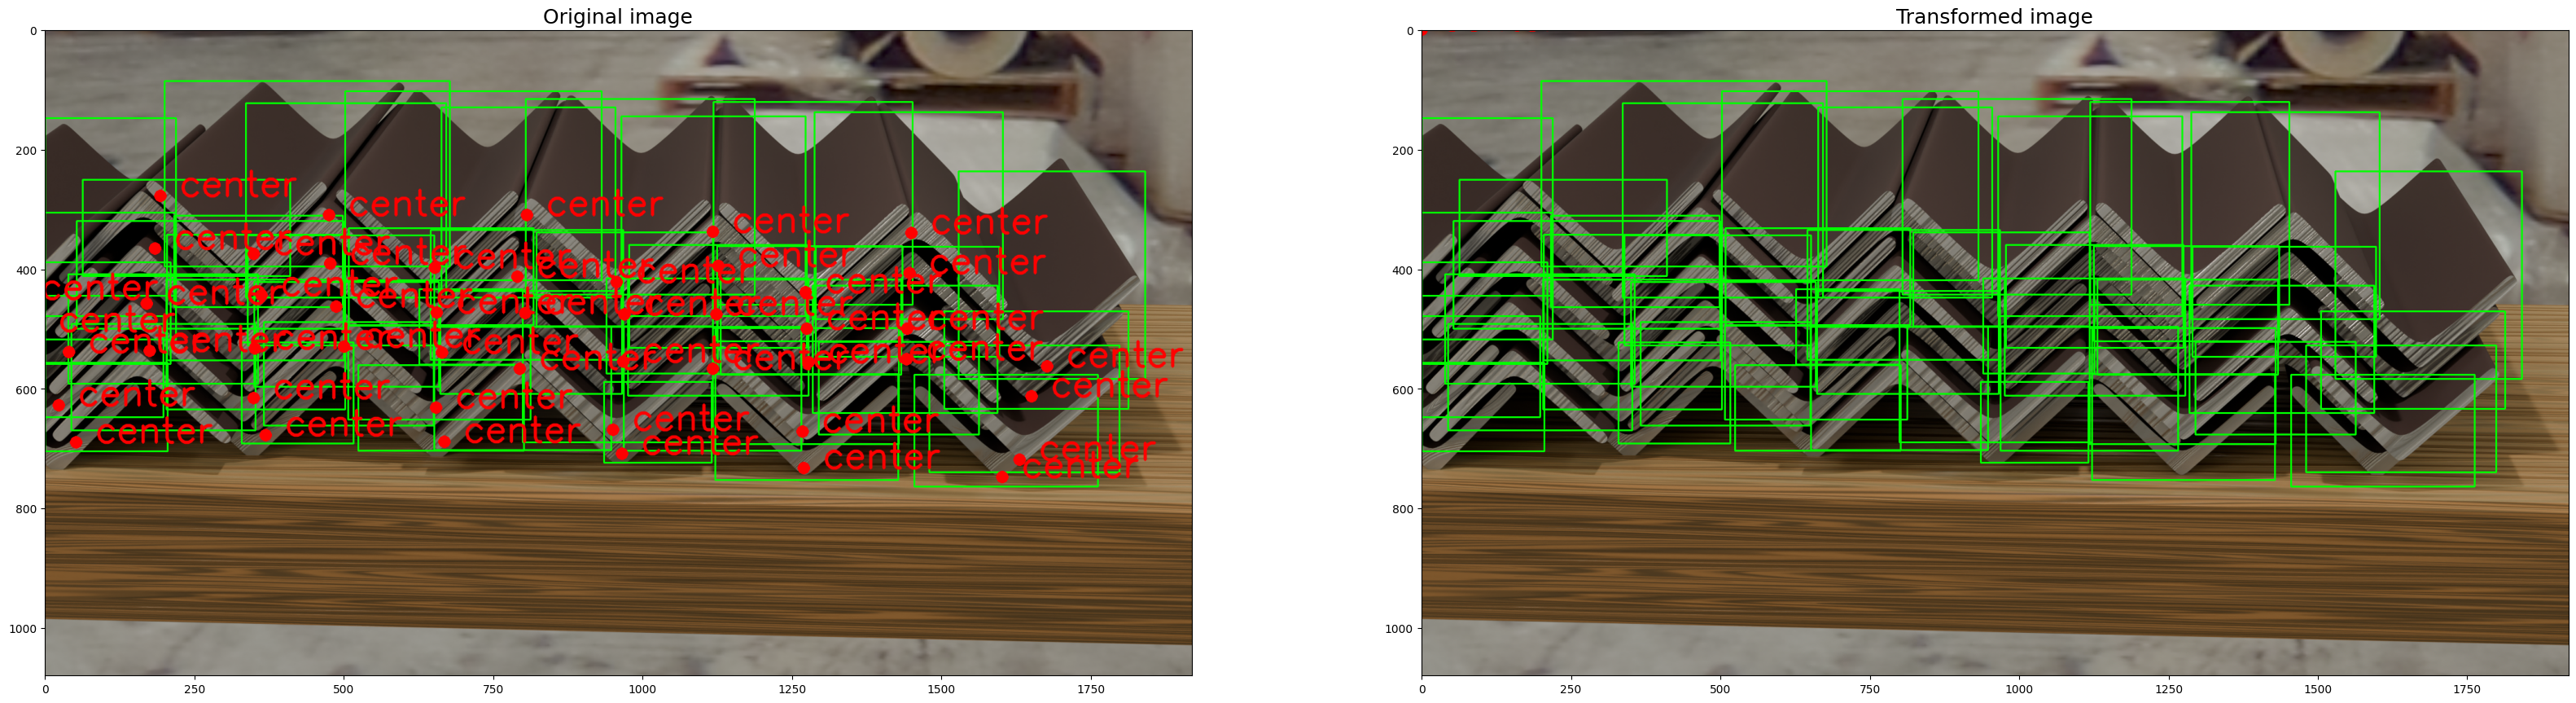

In [12]:
keypoints_classes_ids2names = {0: 'center'}

def visualize(image, bboxes, keypoints, image_original=None, bboxes_original=None, keypoints_original=None):
    fontsize = 18

    for bbox in bboxes:
        start_point = (bbox[0], bbox[1])
        end_point = (bbox[2], bbox[3])
        image = cv2.rectangle(image.copy(), start_point, end_point, (0,255,0), 2)
    
    for kps in keypoints:
        for idx, kp in enumerate(kps):
            image = cv2.circle(image.copy(), tuple(kp), 5, (255,0,0), 10)
            image = cv2.putText(image.copy(), " " + keypoints_classes_ids2names[idx], tuple(kp), cv2.FONT_HERSHEY_SIMPLEX, 2, (255,0,0), 3, cv2.LINE_AA)

    if image_original is None and keypoints_original is None:
        plt.figure(figsize=(40,40))
        plt.imshow(image)

    else:
        for bbox in bboxes_original:
            start_point = (bbox[0], bbox[1])
            end_point = (bbox[2], bbox[3])
            image_original = cv2.rectangle(image_original.copy(), start_point, end_point, (0,255,0), 2)
        
        for kps in keypoints_original:
            for idx, kp in enumerate(kps):
                image_original = cv2.circle(image_original, tuple(kp), 5, (255,0,0), 10)
                image_original = cv2.putText(image_original, " " + keypoints_classes_ids2names[idx], tuple(kp), cv2.FONT_HERSHEY_SIMPLEX, 2, (255,0,0), 3, cv2.LINE_AA)

        f, ax = plt.subplots(1, 2, figsize=(40, 20))

        ax[0].imshow(image_original)
        ax[0].set_title('Original image', fontsize=fontsize)

        ax[1].imshow(image)
        ax[1].set_title('Transformed image', fontsize=fontsize)
        
image = (batch[0][0].permute(1,2,0).numpy() * 255).astype(np.uint8)
bboxes = batch[1][0]['boxes'].detach().cpu().numpy().astype(np.int32).tolist()

keypoints = []
# print debugging information about keypoints
print("batch",batch[1][0]['keypoints'].detach().cpu().numpy().astype(np.int32).tolist())

for kps in batch[1][0]['keypoints'].detach().cpu().numpy().astype(np.int32).tolist():
    # If kps is a flat list (not a list of lists), wrap it in a list
    if isinstance(kps[0], (int, float)):
        keypoints.append([kps[:2]])
    else:
        keypoints.append([kp[:2] for kp in kps])
    # keypoints.append([kp[:2] for kp in kps])

image_original = (batch[2][0].permute(1,2,0).numpy() * 255).astype(np.uint8)
bboxes_original = batch[3][0]['boxes'].detach().cpu().numpy().astype(np.int32).tolist()

keypoints_original = []
for kps in batch[3][0]['keypoints'].detach().cpu().numpy().astype(np.int32).tolist():
    if isinstance(kps[0], (int, float)):
        keypoints_original.append([kps[:2]])
    else:
        keypoints_original.append([kp[:2] for kp in kps])

visualize(image, bboxes, keypoints, image_original, bboxes_original, keypoints_original)

# 5. Training

In [13]:
def get_model(num_keypoints, weights_path=None):
    
    anchor_generator = AnchorGenerator(sizes=(32, 64, 128, 256, 512), aspect_ratios=(0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0))
    model = torchvision.models.detection.keypointrcnn_resnet50_fpn(pretrained=False,
                                                                   pretrained_backbone=True,
                                                                   num_keypoints=num_keypoints,
                                                                   num_classes = 3, # Background is the first class, object is the second class
                                                                   rpn_anchor_generator=anchor_generator)

    if weights_path:
        state_dict = torch.load(weights_path)
        model.load_state_dict(state_dict)        
        
    return model

In [14]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

KEYPOINTS_FOLDER_TRAIN = '.\\datasets\\bars_keypoints\\'
KEYPOINTS_FOLDER_TEST = '.\\datasets\\bars_keypoints\\'

dataset_train = ClassDataset(KEYPOINTS_FOLDER_TRAIN, transform=train_transform(), demo=False)
dataset_test = ClassDataset(KEYPOINTS_FOLDER_TEST, transform=None, demo=False)

data_loader_train = DataLoader(dataset_train, batch_size=3, shuffle=True, collate_fn=collate_fn)
data_loader_test = DataLoader(dataset_test, batch_size=1, shuffle=False, collate_fn=collate_fn)

model = get_model(num_keypoints = 2)
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.001, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.3)
num_epochs = 5

for epoch in range(num_epochs):
    train_one_epoch(model, optimizer, data_loader_train, device, epoch, print_freq=1000)
    lr_scheduler.step()
    evaluate(model, data_loader_test, device)
    
# Save model weights after training
torch.save(model.state_dict(), 'keypointsrcnn_weights.pth')

C:\Users\FLRZ01\AppData\Local\Temp\ipykernel_28376\3432045377.py:5: UserWarning: Argument(s) 'always_apply' are not valid for transform RandomBrightnessContrast
  A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, brightness_by_max=True, always_apply=False, p=1), # Random change of brightness & contrast
c:\Users\FLRZ01\OneDrive - SMS group GmbH\Desktop\dev\tagger\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\FLRZ01\OneDrive - SMS group GmbH\Desktop\dev\tagger\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
c:\Users\FLRZ01\OneDrive - SMS group GmbH\Desktop\dev\tagger\venv\Lib\site-packa

Image: .\datasets\bars_keypoints\images\00029.png, Bboxes: [[542.9999756813049, 1667.9999542236328, 683.000020980835, 1920.0], [467.00000166893005, 1689.9999618530273, 625.9999680519104, 1920.0], [383.0000066757202, 1678.0000305175781, 538.9999973773956, 1875.999984741211], [310.00000834465027, 1667.9999542236328, 505.0000047683716, 1920.0], [156.0000067949295, 1640.0000381469727, 451.9999945163727, 1920.0], [99.99999672174454, 1171.9999694824219, 386.9999849796295, 1685.0000381469727], [118.9999982714653, 924.9999618530273, 413.99999141693115, 1398.9999389648438], [133.99999737739563, 676.9999694824219, 443.0000030994415, 1112.9999542236328], [140.99999964237213, 417.0000457763672, 464.9999964237213, 811.9999694824219], [542.0000052452087, 1377.0000457763672, 679.9999809265137, 1567.0000076293945], [497.999986410141, 1093.0000305175781, 698.0000281333923, 1377.0000457763672], [590.999972820282, 801.0000228881836, 725.0000023841858, 983.9999771118164], [583.9999866485596, 487.000007629

c:\Users\FLRZ01\OneDrive - SMS group GmbH\Desktop\dev\tagger\pytorch_vision\engine.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler is not None):


Epoch: [0]  [ 0/36]  eta: 0:30:56  lr: 0.000030  loss: 10.3362 (10.3362)  loss_classifier: 1.1100 (1.1100)  loss_box_reg: 0.2349 (0.2349)  loss_keypoint: 8.1156 (8.1156)  loss_objectness: 0.6984 (0.6984)  loss_rpn_box_reg: 0.1772 (0.1772)  time: 51.5735  data: 0.3104
Image: .\datasets\bars_keypoints\images\00016.png, Bboxes: [[405.9999704360962, 165.0, 522.0000171661377, 418.00000190734863], [448.99998664855957, 144.0000057220459, 579.9999761581421, 390.0], [509.99998569488525, 233.00000667572021, 632.9999542236328, 393.99999618530273], [542.0000052452087, 122.99999713897705, 670.0000190734863, 363.0000114440918], [583.9999866485596, 100.99999666213989, 766.0000133514404, 380.00000953674316], [640.9999752044678, 393.0000114440918, 813.0000400543213, 757.0000076293945], [629.0000081062317, 618.0000114440918, 803.9999842643738, 945.9999847412109], [618.0000114440918, 843.9999961853027, 800.0000381469727, 1135.9999465942383], [613.0000305175781, 1078.0000305175781, 801.999979019165, 1332.

IndexError: index 3 is out of bounds for dimension 1 with size 0

# 6. Visualizing model predictions

In [ ]:
iterator = iter(data_loader_test)

In [ ]:
images, targets = next(iterator)
images = list(image.to(device) for image in images)

with torch.no_grad():
    model.to(device)
    model.eval()
    output = model(images)

print("Predictions: \n", output)

In [ ]:
image = (images[0].permute(1,2,0).detach().cpu().numpy() * 255).astype(np.uint8)
scores = output[0]['scores'].detach().cpu().numpy()

high_scores_idxs = np.where(scores > 0.7)[0].tolist() # Indexes of boxes with scores > 0.7
post_nms_idxs = torchvision.ops.nms(output[0]['boxes'][high_scores_idxs], output[0]['scores'][high_scores_idxs], 0.3).cpu().numpy() # Indexes of boxes left after applying NMS (iou_threshold=0.3)

# Below, in output[0]['keypoints'][high_scores_idxs][post_nms_idxs] and output[0]['boxes'][high_scores_idxs][post_nms_idxs]
# Firstly, we choose only those objects, which have score above predefined threshold. This is done with choosing elements with [high_scores_idxs] indexes
# Secondly, we choose only those objects, which are left after NMS is applied. This is done with choosing elements with [post_nms_idxs] indexes

keypoints = []
for kps in output[0]['keypoints'][high_scores_idxs][post_nms_idxs].detach().cpu().numpy():
    keypoints.append([list(map(int, kp[:2])) for kp in kps])

bboxes = []
for bbox in output[0]['boxes'][high_scores_idxs][post_nms_idxs].detach().cpu().numpy():
    bboxes.append(list(map(int, bbox.tolist())))
    
visualize(image, bboxes, keypoints)